In [1]:
### Improvement over LazyVisualizeData_v2_lazy.ipynb (v3) as we now outsource the 2D slice extraction to  
### adrienExportSlicesNetCDF.ipynb or equivalently adrienExportSlicesNetCDFAuto.py (which can be run as a batch script)
### These export the slices as NetCDF files and then the current notebook load sthem. However even this slicing in python
### (done as I do it) is pretty slow and struggles for the largest cases R4P50, R8P7, R10P7.
### ALL ROUTINES ARE IN adrienUtils.py and the case parameters and file paths are in adrienParamClassSheared.py
### Adrien Lefauve, Feburary 2026

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
from pathlib import Path

import adrienParamClassSheared as params
import adrienUtils as utils
importlib.reload(params);
importlib.reload(utils);

In [18]:
# pick a case
cases = params.generate()
p = cases["R8P1"]

# where you saved slices
slice_dir = Path(p.dirPath) / "2D_slices"
print("slice_dir:", slice_dir)

# the three files you created
paths = {
    "xy": slice_dir / "xy.nc",
    "xz": slice_dir / "xz.nc",
    "yz": slice_dir / "yz.nc",
}

planes_ok = [
    pl for pl, path in paths.items()
    if path.exists() and path.stat().st_size > 0
]

print("planes_ok:", planes_ok)

# buoyancy frequency for this run (needed for Ep and bN)
p.N2 = float(-p.dGrad * p.zAccel)
p.N  = float(np.sqrt(p.N2))

print("N2 =", p.N2)
print("N  =", p.N)

slice_dir: /lustre/orion/cfd135/proj-shared/Hsst/R8P1/001_Final/2D_slices
planes_ok: ['xy', 'xz', 'yz']
N2 = 0.15
N  = 0.3872983346207417


In [19]:
stats_by_plane = {}

for pl in planes_ok:
    path = paths[pl]
    raw, attrs = utils.read_raw_plane_netcdf(path, copy=True)
    st = utils.plane_stats(raw, p)
    stats_by_plane[pl] = st

    fixed = {"xy":"iz", "xz":"iy", "yz":"ix"}[pl]
    print(f"[{pl}] {fixed}={attrs.get(fixed, '??')}  "
          f"Ek={st['Ek']:.6e}  Ep={st['Ep']:.6e}  "
          f"eps={st['eps_avg']:.6e}  chi={st['chi_avg']:.6e}", flush=True)

# combine (simple mean across the three planes)
stats = {k: float(np.mean([stats_by_plane[pl][k] for pl in stats_by_plane]))
         for k in ["Ek","Ep","eps_avg","chi_avg"]}

print("\n[combined stats from 2D slices]")
for k, v in stats.items():
    print(f"  {k}: {v:.6e}")

Ek_slice = stats["Ek"]
Ek_pct = Ek_slice / p.targKE * 100.0

print(f"2D averaged Ek  is {Ek_pct:.2f}% of 3D average (target)")

[xy] iz=1092  Ek=2.290623e-02  Ep=1.905591e-03  eps=3.461732e-03  chi=7.089583e-04
[xz] iy=2184  Ek=1.095215e-02  Ep=1.112578e-03  eps=1.780306e-03  chi=3.662852e-04
[yz] ix=4368  Ek=1.531365e-02  Ep=1.350006e-03  eps=2.165149e-03  chi=4.303773e-04

[combined stats from 2D slices]
  Ek: 1.639068e-02
  Ep: 1.456058e-03
  eps_avg: 2.469062e-03
  chi_avg: 5.018736e-04
2D averaged Ek  is 103.79% of 3D average (target)


In [20]:
# --- read all planes ---
raw2d = {}
meta2d = {}

def is_valid_netcdf3(path, min_bytes=256):
    path = Path(path)
    if (not path.exists()) or path.stat().st_size < min_bytes:
        return False
    with open(path, "rb") as f:
        return f.read(3) == b"CDF"   # NetCDF3 signature

# IMPORTANT: reuse the same filtering logic as earlier, but stronger than st_size>0
planes_ok = [pl for pl in ["xy", "xz", "yz"] if is_valid_netcdf3(paths[pl])]
print("planes_ok:", planes_ok)

for pl in planes_ok:
    raw2d[pl], meta2d[pl] = utils._read_plane_nc(paths[pl])
    print(pl, "loaded:", {k: raw2d[pl][k].shape for k in raw2d[pl].keys()})
    
# --- build a SliceBundle 's' containing ONLY derived fields (like get_derived_slices_multi) ---
# We reuse your SliceBundle / VarSlices classes already in adrienUtils.
out_vars = {name: utils.VarSlices(name) for name in ["uN", "vN", "wN", "bN", "epslog", "chilog"]}

Ek = stats["Ek"]
Ep = stats["Ep"]
eps_avg = stats["eps_avg"]
chi_avg = stats["chi_avg"]
N2 = float(p.N2)  # you set this earlier in Cell 5

tiny = 1e-30

for pl in raw2d.keys():
    u2 = raw2d[pl]["u"]
    v2 = raw2d[pl]["v"]
    w2 = raw2d[pl]["w"]
    r2 = raw2d[pl]["r"]
    ee2 = raw2d[pl]["ee"]
    chi2 = raw2d[pl]["chi"]

    out_vars["uN"].set(pl, u2 / np.sqrt(Ek))
    out_vars["vN"].set(pl, v2 / np.sqrt(Ek))
    out_vars["wN"].set(pl, w2 / np.sqrt(Ek))

    out_vars["bN"].set(pl, r2 * (-p.zAccel) / np.sqrt(N2 * Ep))

    with np.errstate(divide="ignore", invalid="ignore"):
        out_vars["epslog"].set(pl, np.log10(np.maximum(ee2, tiny) / eps_avg))
        out_vars["chilog"].set(pl, np.log10(np.maximum(chi2, tiny) / chi_avg))

# idx is not super meaningful here, but keep it for compatibility with plotting funcs
idx_map = {
    "xy": int(meta2d["xy"]["attrs"].get("iz", -1)) if "xy" in meta2d else -1,
    "xz": int(meta2d["xz"]["attrs"].get("iy", -1)) if "xz" in meta2d else -1,
    "yz": int(meta2d["yz"]["attrs"].get("ix", -1)) if "yz" in meta2d else -1,
}

# use any available plane to read stride (they are identical)
first_pl = next(iter(meta2d.keys()))

stride_tuple = (
    int(meta2d[first_pl]["attrs"].get("stride_x", 1)),
    int(meta2d[first_pl]["attrs"].get("stride_y", 1)),
    int(meta2d[first_pl]["attrs"].get("stride_z", 1)),
)

s = utils.SliceBundle(vars=out_vars, idx=idx_map, stride=stride_tuple)

print("planes:", s.available_planes())
print("vars:", s.available_vars())
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.01)

planes_ok: ['xy', 'xz', 'yz']
xy loaded: {'u': (8736, 4368), 'v': (8736, 4368), 'w': (8736, 4368), 'r': (8736, 4368), 'ee': (8736, 4368), 'chi': (8736, 4368)}
xz loaded: {'u': (8736, 2184), 'v': (8736, 2184), 'w': (8736, 2184), 'r': (8736, 2184), 'ee': (8736, 2184), 'chi': (8736, 2184)}
yz loaded: {'u': (4368, 2184), 'v': (4368, 2184), 'w': (4368, 2184), 'r': (4368, 2184), 'ee': (4368, 2184), 'chi': (4368, 2184)}
planes: ['xy', 'xz', 'yz']
vars: ['uN', 'vN', 'wN', 'bN', 'epslog', 'chilog']
u2                          0.04 GB  shape=(4368, 2184)  dtype=float32
v2                          0.04 GB  shape=(4368, 2184)  dtype=float32
w2                          0.04 GB  shape=(4368, 2184)  dtype=float32
r2                          0.04 GB  shape=(4368, 2184)  dtype=float32
ee2                         0.04 GB  shape=(4368, 2184)  dtype=float32
chi2                        0.04 GB  shape=(4368, 2184)  dtype=float32

Notebook memory used     :   8.74 GB (  6.8 %)
Remaining available to me: 119.

Saved -> figures/R8P1_all_variables_z1092_20260204_133855.png
Saved -> figures/R8P1_all_variables_y2184_20260204_133915.png
Saved -> figures/R8P1_all_variables_x4368_20260204_133928.png


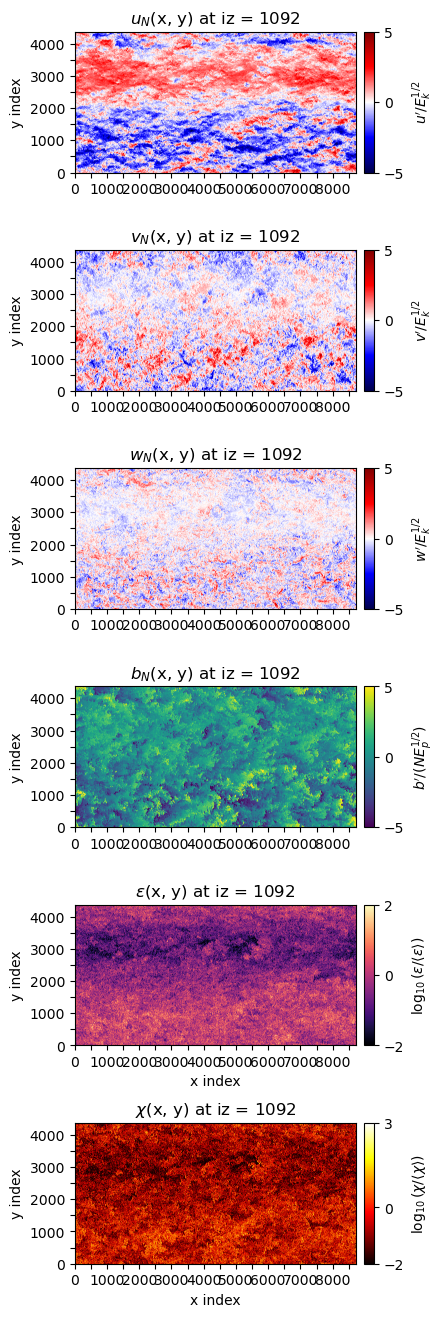

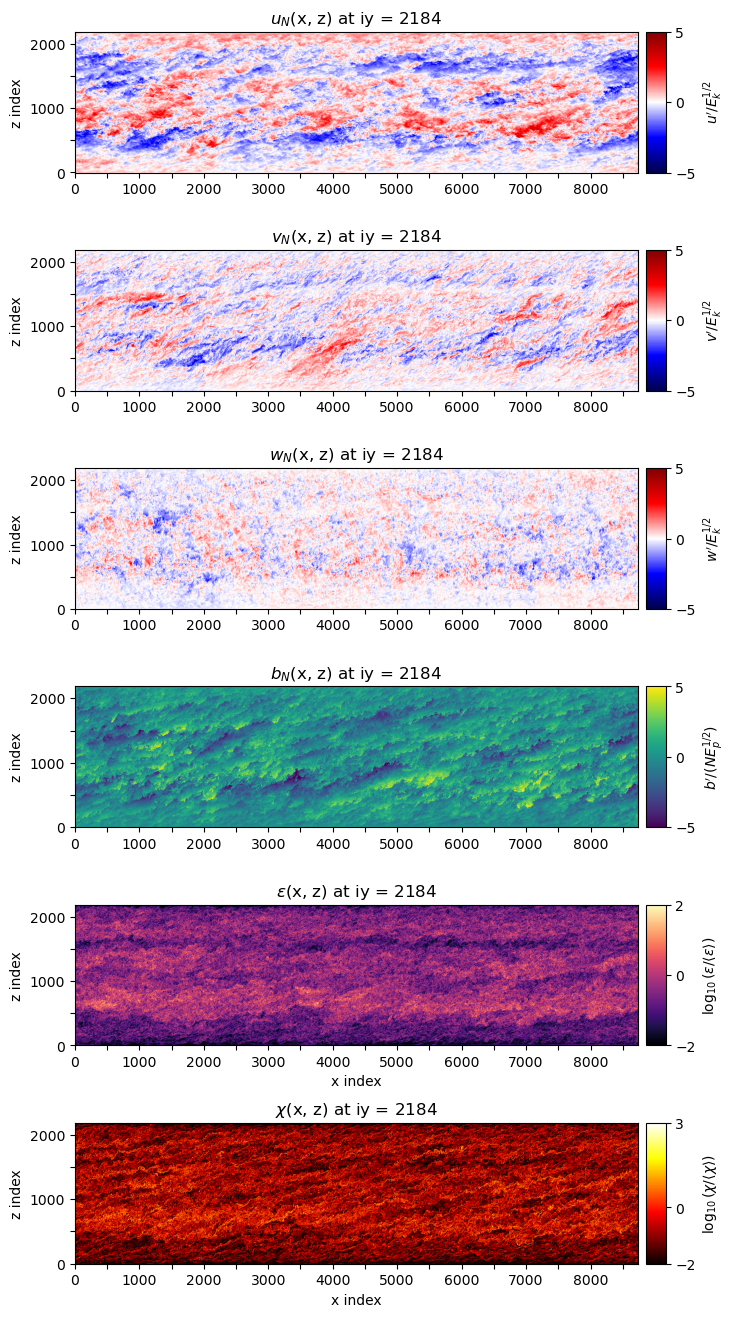

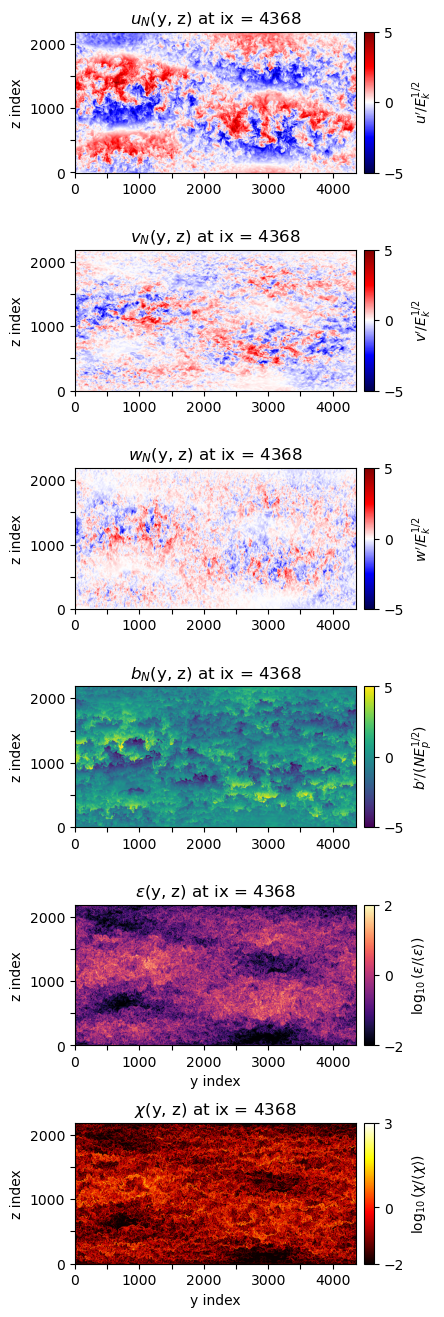

In [21]:
# PLOT A SUMMARY FIGURE FOR EACH SLICE, ALL 6 VARIABLES, AT LOW RESOLUTION 
# use only planes that exist in the bundle (safe even if only one plane)
planes_avail = tuple(pl for pl in ("xy","xz","yz") if pl in s.available_planes())

if not planes_avail:
    raise RuntimeError("No planes available in SliceBundle 's' (nothing to plot).")

figs = utils.plot_slices_derived_bundle_multi(
    p, s,
    planes=planes_avail,
    save=True, outdir="figures", fmt="png", dpi=300
)

In [22]:
# PLOT FULL RESOLUTION FOR EACH VARIABLE

# stride controls resolution of output (1,1,1 = full res)
stride = (1, 1, 1)

planes_avail = tuple(pl for pl in ("xy", "xz", "yz") if pl in s.available_planes())

if not planes_avail:
    raise RuntimeError("No planes available in SliceBundle 's' (nothing to export).")

paths = utils.export_native_resolution_from_bundle_multi(
    p, s,
    planes=planes_avail,
    outdir="figures"
)

paths
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.01)

u2                          0.04 GB  shape=(4368, 2184)  dtype=float32
v2                          0.04 GB  shape=(4368, 2184)  dtype=float32
w2                          0.04 GB  shape=(4368, 2184)  dtype=float32
r2                          0.04 GB  shape=(4368, 2184)  dtype=float32
ee2                         0.04 GB  shape=(4368, 2184)  dtype=float32
chi2                        0.04 GB  shape=(4368, 2184)  dtype=float32

Notebook memory used     :   6.88 GB (  5.4 %)
Remaining available to me: 121.12 GB ( 94.6 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB
